In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Data Loading

In [ ]:
# loading VIs data extracted from imgs and annotation data
df1 = pd.read_csv('final_indices_sickel.csv')
df2 = pd.read_csv('clean_data_annotations.csv')

In [ ]:
df1.head(2)

,UNIQUE_ID,Folder Name,NDVI_mean,NDWI_mean,EVI_mean,SAVI_mean,ARVI_mean,GCI_mean,MSI_mean,GLA_mean,...,VARI_mean,ExR_mean,ExG_mean,ExGR_mean,ACQ_YEAR,ACQ_START_DATE,ACQ_END_DATE,ACQ_MONTH,ACQ_DAY,ACQ_TIME
0,0,20180605T045701_20180605T045701_T44PKT,0.5204,0.7742,1.455,0.7296,0.432,2.064,0.2054,0.0928,...,0.039,389.0731,383.2048,-5.8683,2018,2018-06-05,2018-06-05,6,5,04:57:01
1,0,20181031T050929_20181031T050929_T44PKT,NaN,NaN,0.000,0.0000,NaN,NaN,NaN,NaN,...,NaN,0.0000,0.0000,0.0000,2018,2018-10-31,2018-10-31,10,31,05:09:29


In [ ]:
df2.head(2)

,UNIQUE_ID,PLOT_ID,RIVER_PART,STANDARD_SEASON,YEAR,AREA,CROP,VARIETY,PADDY_BIN,SOWING_DATE,TRANSPLANTING_DATE,HARVESTING_DATE,SOWING_DAY,TRANSPLANTING_DAY,HARVESTING_DAY,YIELD,SEASON_DURATION
0,0,1,Upper Cauvery,jun-oct,2018,0.32,Coconut,Unknown,0,NaN,NaN,NaN,0,0,0,0.0,153
1,1,1,Upper Cauvery,aug-jan,2018,0.32,Coconut,Unknown,0,NaN,NaN,NaN,0,0,0,0.0,184


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126503 entries, 0 to 126502
Data columns (total 22 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Folder No       126503 non-null  int64  
 1   Folder Name     126503 non-null  object 
 2   NDVI_mean       120976 non-null  float64
 3   NDWI_mean       120976 non-null  float64
 4   EVI_mean        126503 non-null  float64
 5   SAVI_mean       126503 non-null  float64
 6   ARVI_mean       120976 non-null  float64
 7   GCI_mean        120976 non-null  float64
 8   MSI_mean        120976 non-null  float64
 9   GLA_mean        120976 non-null  float64
 10  WI_mean         120973 non-null  float64
 11  NGRDI_mean      120976 non-null  float64
 12  RGBVI_mean      120976 non-null  float64
 13  VARI_mean       120976 non-null  float64
 14  ExR_mean        126503 non-null  float64
 15  ExG_mean        126503 non-null  float64
 16  ExGR_mean       126503 non-null  float64
 17  ACQ_YEAR  

* data cleaning required on indices_sickle_data

In [ ]:
# changing the datatype of ACQ_START_DATE, ACQ_END_DATE
df1["ACQ_START_DATE"] = pd.to_datetime(df1["ACQ_START_DATE"], format="%Y-%m-%d %H:%M:%S")
df1["ACQ_END_DATE"] = pd.to_datetime(df1["ACQ_END_DATE"], format="%Y-%m-%d %H:%M:%S")

* seperating aquisition date and time

In [ ]:
df1["ACQ_TIME"] = df1["ACQ_START_DATE"].dt.time
df1["ACQ_START_DATE"] = df1["ACQ_START_DATE"].dt.date
df1["ACQ_END_DATE"] = df1["ACQ_END_DATE"].dt.date

In [ ]:
# need to change data type again
df1["ACQ_START_DATE"] = pd.to_datetime(df1["ACQ_START_DATE"], format="%Y/%m/%d")
df1["ACQ_END_DATE"] = pd.to_datetime(df1["ACQ_END_DATE"], format="%Y/%m/%d")

* chnage column name of folder no

In [ ]:
df1 = df1.rename(columns={"Folder No": "UNIQUE_ID"})

* Merging two dataframes

In [ ]:
df = pd.merge(df1, df2, left_on="UNIQUE_ID", right_on="UNIQUE_ID", how="inner")

In [ ]:
df.sample(2)

,UNIQUE_ID,Folder Name,NDVI_mean,NDWI_mean,EVI_mean,SAVI_mean,ARVI_mean,GCI_mean,MSI_mean,GLA_mean,...,VARIETY,PADDY_BIN,SOWING_DATE,TRANSPLANTING_DATE,HARVESTING_DATE,SOWING_DAY,TRANSPLANTING_DAY,HARVESTING_DAY,YIELD,SEASON_DURATION
49104,979,20210105T050209_20210105T050811_T44PLS,0.0022,0.8941,-0.0073,0.0034,0.0758,-0.0614,0.0662,0.0008,...,Unknown,1,2021-01-01,NaN,2021-05-31,32,0,182,0.0,182
56365,1209,20200930T050659_20200930T051836_T44PKT,0.0467,0.7322,-0.2547,0.0701,0.0870,0.0543,0.2633,0.0015,...,Unknown,1,2020-09-01,NaN,2020-12-31,32,0,153,0.0,184


#### Data Cleaning

In [ ]:
# size of merged data
df.shape

(105928, 39)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105928 entries, 0 to 105927
Data columns (total 39 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   UNIQUE_ID           105928 non-null  int64         
 1   Folder Name         105928 non-null  object        
 2   NDVI_mean           101694 non-null  float64       
 3   NDWI_mean           101694 non-null  float64       
 4   EVI_mean            105928 non-null  float64       
 5   SAVI_mean           105928 non-null  float64       
 6   ARVI_mean           101694 non-null  float64       
 7   GCI_mean            101694 non-null  float64       
 8   MSI_mean            101694 non-null  float64       
 9   GLA_mean            101694 non-null  float64       
 10  WI_mean             101694 non-null  float64       
 11  NGRDI_mean          101694 non-null  float64       
 12  RGBVI_mean          101694 non-null  float64       
 13  VARI_mean           101694 no

* Removing unnecessary columns

In [ ]:
# renaming columns
df.drop(columns=["Folder Name"], inplace=True)

In [ ]:
# checking for duplicates in dataset
df.duplicated().sum()

np.int64(31)

In [ ]:
# viewing the duplicates
df[df.duplicated()]

,UNIQUE_ID,NDVI_mean,NDWI_mean,EVI_mean,SAVI_mean,ARVI_mean,GCI_mean,MSI_mean,GLA_mean,WI_mean,...,VARIETY,PADDY_BIN,SOWING_DATE,TRANSPLANTING_DATE,HARVESTING_DATE,SOWING_DAY,TRANSPLANTING_DAY,HARVESTING_DAY,YIELD,SEASON_DURATION
31847,664,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Unknown,0,NaN,NaN,NaN,0,0,0,0.0,182
32110,666,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Unknown,0,NaN,NaN,NaN,0,0,0,0.0,182
35789,713,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Unknown,0,NaN,NaN,NaN,0,0,0,0.0,153
35794,713,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Unknown,0,NaN,NaN,NaN,0,0,0,0.0,153
35808,713,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Unknown,0,NaN,NaN,NaN,0,0,0,0.0,153
35812,713,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Unknown,0,NaN,NaN,NaN,0,0,0,0.0,153
35821,713,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Unknown,0,NaN,NaN,NaN,0,0,0,0.0,153
35824,713,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Unknown,0,NaN,NaN,NaN,0,0,0,0.0,153
35834,713,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Unknown,0,NaN,NaN,NaN,0,0,0,0.0,153
35842,713,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Unknown,0,NaN,NaN,NaN,0,0,0,0.0,153


In [ ]:
# remove duplicate values
df = df.drop_duplicates()

In [ ]:
# size after removing duplicates
df.shape

(105897, 38)

* HeapMap For Null-values

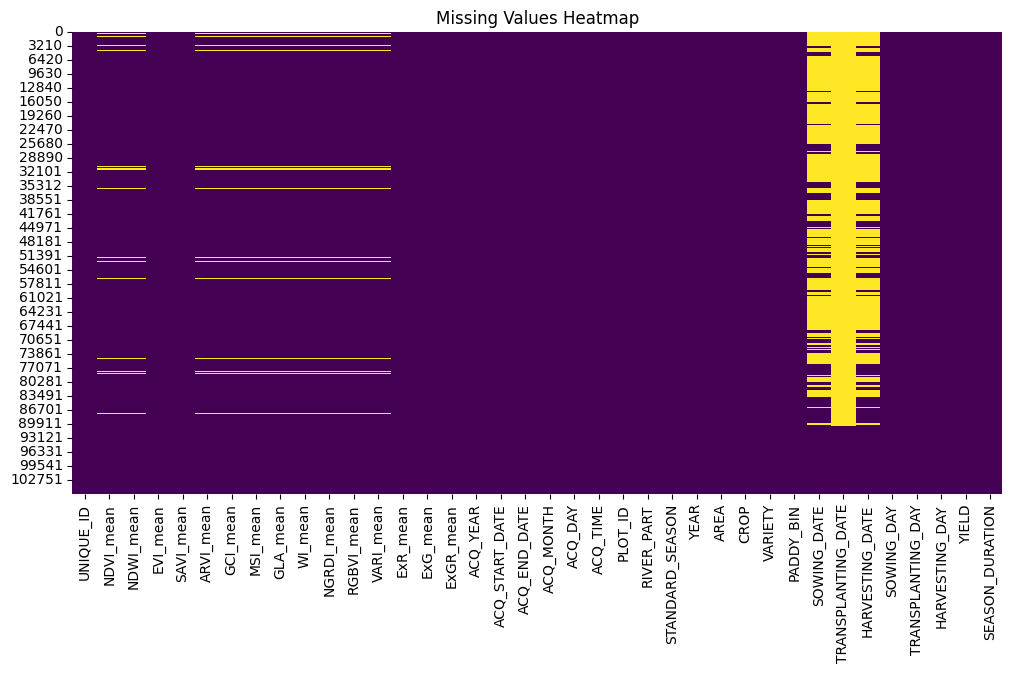

In [ ]:
# heapmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

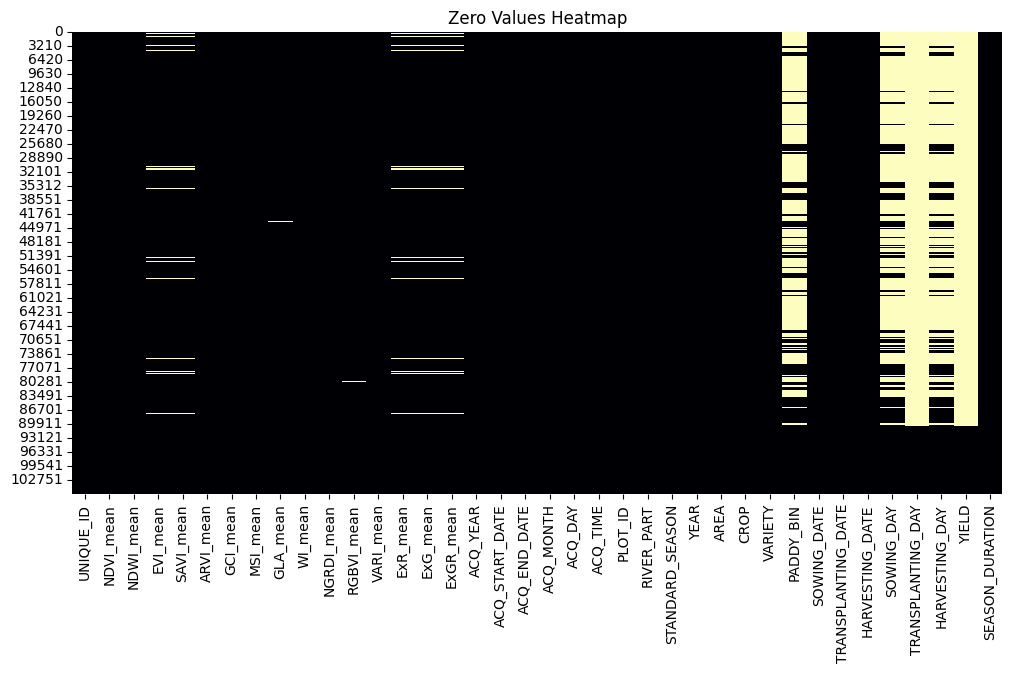

In [ ]:
# heapmap for zeros
plt.figure(figsize=(12, 6))
sns.heatmap(df == 0, cbar=False, cmap="magma")
plt.title("Zero Values Heatmap")
plt.show()

In [ ]:
# making copy
df_copy = df.copy()

* consider data for only paddy crop

In [ ]:
df = df[df["PADDY_BIN"] != 0]

In [ ]:
df = df.drop(columns=["PADDY_BIN"])

In [ ]:
# size after removing other crops
df.shape

(41819, 38)

* Replace the zeros with null

In [ ]:
# replace all 0 values with null
df = df.replace(0, np.nan)

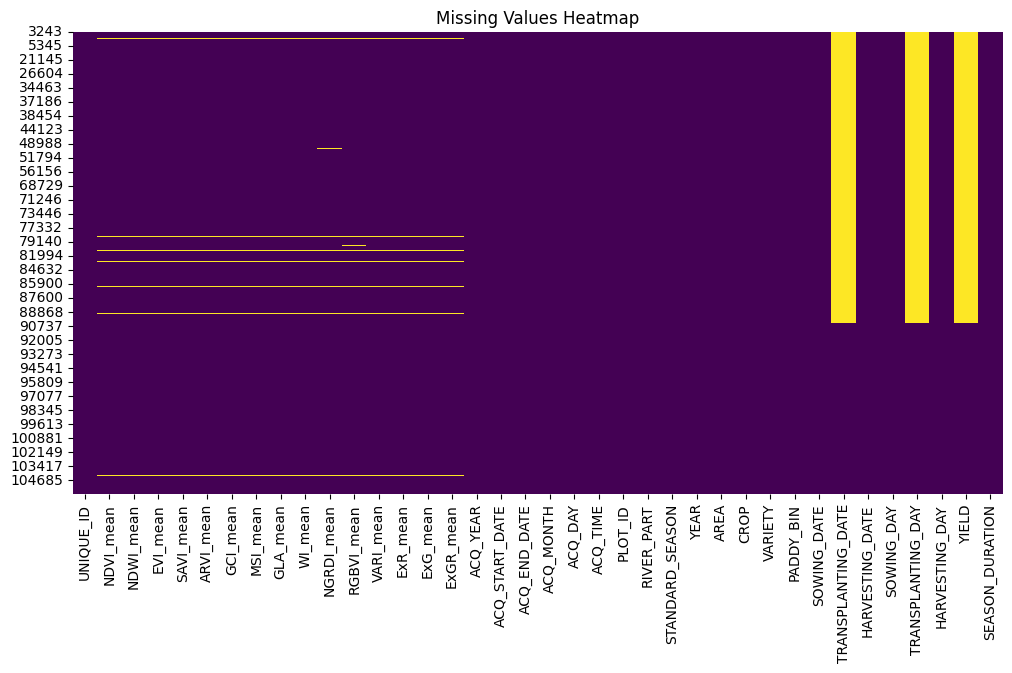

In [ ]:
# now check for null values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

* drop rows with Null values

In [ ]:
df = df.dropna()

In [ ]:
df.shape

(15377, 38)

In [ ]:
df.to_csv("final_dataset.csv", index=False)

#### Data Preprocessing

In [ ]:
# changing datatype
df["HARVESTING_DATE"] = pd.to_datetime(df["HARVESTING_DATE"], format="%Y-%m-%d")
df["SOWING_DATE"] = pd.to_datetime(df["SOWING_DATE"], format="%Y-%m-%d")
df["TRANSPLANTING_DATE"] = pd.to_datetime(df["TRANSPLANTING_DATE"], format="%Y-%m-%d")

In [ ]:
# calculating growth duration
df['DAYS_SOW_TO_HARVEST'] = (df['HARVESTING_DATE'] - df['SOWING_DATE']).dt.days
df['DAYS_TRANS_TO_HARVEST'] = (df['HARVESTING_DATE'] - df['TRANSPLANTING_DATE']).dt.days
df['SOWING_DOY'] = df['SOWING_DATE'].dt.dayofyear

In [ ]:
df.sample(5)

,UNIQUE_ID,NDVI_mean,NDWI_mean,EVI_mean,SAVI_mean,ARVI_mean,GCI_mean,MSI_mean,GLA_mean,WI_mean,...,TRANSPLANTING_DATE,HARVESTING_DATE,SOWING_DAY,TRANSPLANTING_DAY,HARVESTING_DAY,YIELD,SEASON_DURATION,DAYS_SOW_TO_HARVEST,DAYS_TRANS_TO_HARVEST,SOWING_DOY
95552,2144,0.0206,0.8977,-0.2687,0.0309,0.0162,0.0377,0.0634,0.0043,-2.8781,...,2020-10-14,2021-03-11,-20,14.0,162,1800.0,182,182,148,254
92965,2096,0.3730,0.7348,1.4203,0.5594,0.2889,1.3991,0.2744,0.0178,0.8940,...,2019-12-08,2020-03-29,34,69.0,181,1680.0,183,147,112,307
90945,2068,0.0459,0.8801,-0.5985,0.0688,0.0459,0.0837,0.0774,0.0057,-1.1226,...,2019-11-08,2020-03-08,3,39.0,160,2040.0,183,157,121,276
104588,2363,0.0557,0.7416,-0.3295,0.0836,0.0775,0.0972,0.2538,0.0027,0.9178,...,2020-06-03,2020-08-22,3,34.0,114,1920.0,153,111,80,124
98592,2208,0.5287,0.8080,15.0559,0.7929,0.5930,1.5467,0.1562,0.0976,-0.4659,...,2020-10-12,2021-02-22,11,42.0,175,1860.0,181,164,133,255


#### Outliers

In [ ]:
# code to find and remove the outliers

#### Feature Selection

* Correlation matrix

Purpose:
   1. Identify which features have linear relationship with target YIELD
   2. Quick & easy first filter
   3. High correlation ≠ guaranteed good feature, but good indicator

In [ ]:
# Only keep numeric columns
df_num = df.select_dtypes(include=['int64', 'float64'])

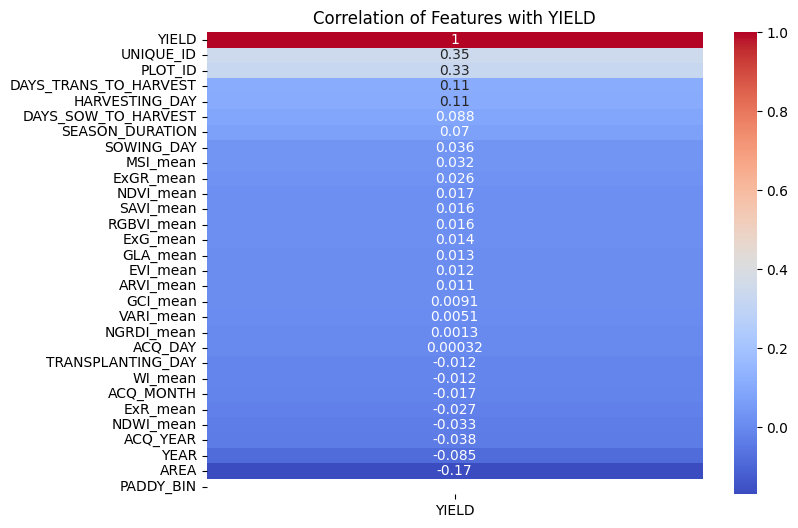

In [ ]:
corr = df_num.corr()

# heapmap for correlation
plt.figure(figsize=(8,6))
sns.heatmap(
    corr[['YIELD']].sort_values(by='YIELD', ascending=False),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation of Features with YIELD")
plt.show()

Conclusion: Vegetation-index-to-yield relationship is not linear.

* Multicollinearity Removal

Purpose:
   1. Many vegetation indices are highly correlated with each other
   2. Too many similar features confuse the model


In [ ]:
# checking for correlation btw VIs
vi_cols = [
    'NDVI_mean', 'EVI_mean', 'SAVI_mean', 'VARI_mean', 'RGBVI_mean',
    'ExG_mean', 'ExR_mean', 'ExGR_mean', 'NGRDI_mean',
    'GLA_mean', 'WI_mean', 'NDWI_mean',
    'G_R', 'R_B', 'G_B'
]

# Keep only those that actually exist
vi_cols = [col for col in vi_cols if col in df.columns]

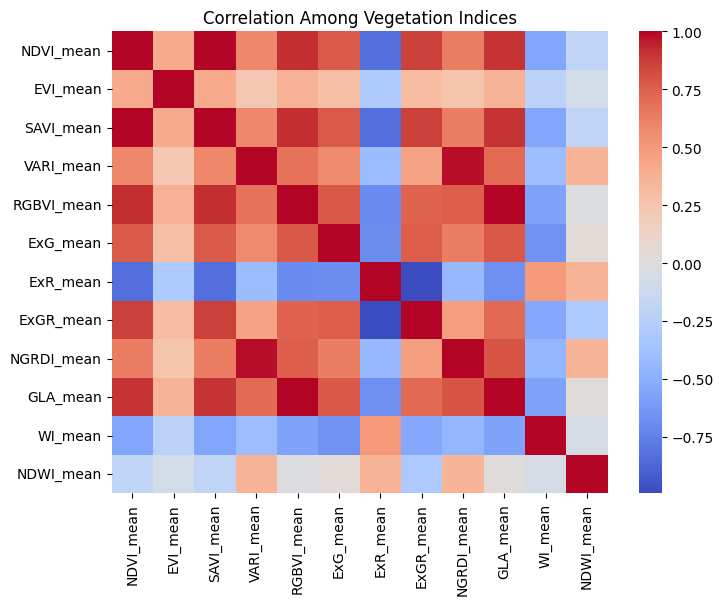

In [ ]:
corr_vi = df[vi_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_vi, annot=False, cmap='coolwarm')
plt.title("Correlation Among Vegetation Indices")
plt.show()

In [ ]:
# identify highly correlated VIs (> 0.90)
corr_matrix = corr_vi.abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

print("Highly correlated vegetation indices to drop:", high_corr_drop)

Highly correlated vegetation indices to drop: ['SAVI_mean', 'RGBVI_mean', 'ExGR_mean', 'NGRDI_mean', 'GLA_mean']


`['SAVI_mean', 'RGBVI_mean', 'ExGR_mean', 'NGRDI_mean', 'GLA_mean']`  
These are the columns with multicollinearity

We nned to remove them as **highly correlated features give duplicate information**

Duplicate features confuse ML models

→ Unstable model

→ Overfitting

→ Wrong feature importance

→ Bad generalisation

In [ ]:
# Remove highly correlated features
drop_vi = ['SAVI_mean', 'RGBVI_mean', 'ExGR_mean', 'NGRDI_mean', 'GLA_mean']
df = df.drop(columns=drop_vi, errors='ignore')

# check remaining columns
df.sample(3)

,UNIQUE_ID,NDVI_mean,NDWI_mean,EVI_mean,ARVI_mean,GCI_mean,MSI_mean,WI_mean,VARI_mean,ExR_mean,...,TRANSPLANTING_DATE,HARVESTING_DATE,SOWING_DAY,TRANSPLANTING_DAY,HARVESTING_DAY,YIELD,SEASON_DURATION,DAYS_SOW_TO_HARVEST,DAYS_TRANS_TO_HARVEST,SOWING_DOY
92886,2095,0.0782,0.8322,-0.3315,0.1455,0.0966,0.1227,0.9416,0.0711,1423.9431,...,2020-07-20,2020-10-20,15,50.0,142,1440.0,153,127,92,167
92211,2089,0.0162,0.8818,-0.2615,0.0062,0.0394,0.0755,3.3277,-0.0062,3167.3248,...,2020-12-08,2021-03-08,34,69.0,159,1920.0,182,125,90,308
101870,2294,0.4787,0.8081,-7.6029,0.5672,1.1952,0.1588,-0.3617,0.2813,86.2193,...,2020-10-11,2021-01-26,11,41.0,148,2160.0,181,137,107,255


* Model Based Feature Importance

Purpose:

  1. Identify non-linear, complex interactions

  2. Very reliable

In [ ]:
from sklearn.ensemble import RandomForestRegressor

y = df['YIELD']  # target variable
X = df.select_dtypes(include=['int64', 'float64']).drop(columns=['YIELD'], errors='ignore') # featues

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X, y)

# get feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(20)

,0
UNIQUE_ID,3.399837e-01
PLOT_ID,2.608819e-01
AREA,1.264501e-01
DAYS_TRANS_TO_HARVEST,8.221620e-02
TRANSPLANTING_DAY,5.841067e-02
HARVESTING_DAY,5.079494e-02
SEASON_DURATION,4.730426e-02
DAYS_SOW_TO_HARVEST,1.588919e-02
SOWING_DAY,9.492645e-03
YEAR,7.615705e-03


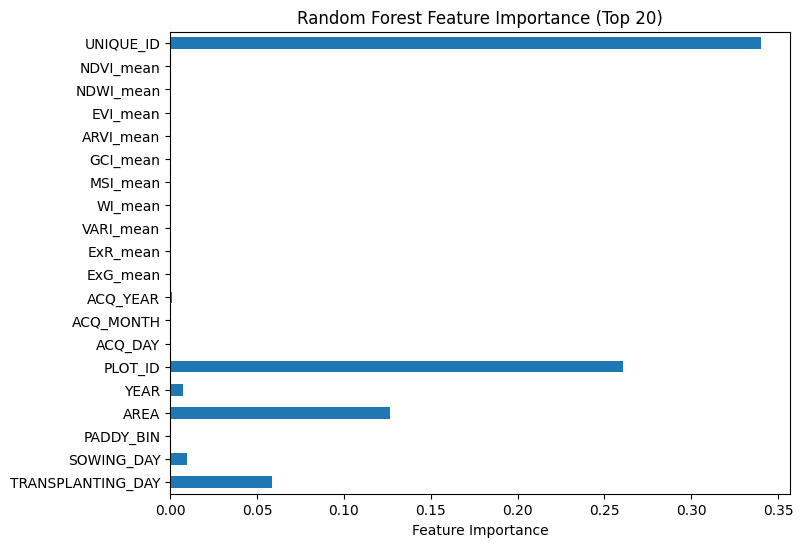

In [ ]:
# Plot features importance
plt.figure(figsize=(8,6))
importances.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance (Top 20)")
plt.show()

Conclusion: `[UNIQUE_ID, PLOT_ID, AREA]`
**These features should be removed** BEFORE training Random Forest
Otherwise the model learns pattern from IDs instead of vegetation indices.

In [ ]:
# drop the unnessary features
df_clean = df.drop(columns=[
    'UNIQUE_ID',
    'PLOT_ID',
    'YEAR',
    'ACQ_YEAR',
    'SOWING_DAY',
    'TRANSPLANTING_DAY',
    'HARVESTING_DAY',
], errors='ignore')

In [ ]:
y = df_clean['YIELD'] # target variable
X = df_clean.select_dtypes(include=['int64', 'float64']).drop(columns=['YIELD'], errors='ignore')

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None,
    n_jobs=-1
)

rf.fit(X, y)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
rf_importances = pd.Series(rf.feature_importances_, index=X.columns)
rf_importances = rf_importances.sort_values(ascending=False)

print(rf_importances)

DAYS_TRANS_TO_HARVEST    0.360640
DAYS_SOW_TO_HARVEST      0.323134
AREA                     0.120403
SEASON_DURATION          0.115610
VARI_mean                0.011022
ExG_mean                 0.009532
WI_mean                  0.008914
ARVI_mean                0.008028
EVI_mean                 0.007224
NDWI_mean                0.007142
ExR_mean                 0.007103
MSI_mean                 0.006955
GCI_mean                 0.004808
NDVI_mean                0.004344
ACQ_DAY                  0.003172
ACQ_MONTH                0.001969
dtype: float64


In [ ]:
# Remove ultra-low importance features (below 0.002)
cols_to_remove = ['ACQ_DAY', 'ACQ_MONTH']
df_clean = df_clean.drop(columns=cols_to_remove, errors='ignore')

# check remaining columns
df_clean.sample(3)

,NDVI_mean,NDWI_mean,EVI_mean,ARVI_mean,GCI_mean,MSI_mean,WI_mean,VARI_mean,ExR_mean,ExG_mean,...,CROP,VARIETY,SOWING_DATE,TRANSPLANTING_DATE,HARVESTING_DATE,YIELD,SEASON_DURATION,DAYS_SOW_TO_HARVEST,DAYS_TRANS_TO_HARVEST,SOWING_DOY
102152,0.2794,0.7600,0.5851,0.1103,1.0154,0.2960,0.7951,-0.0558,557.2700,231.0101,...,Paddy,CR,2020-09-09,2020-10-08,2021-02-25,2160.0,181,169,140,253
104455,0.4172,0.7424,-1.7547,0.3718,1.4493,0.2730,-0.1525,0.0457,364.5614,171.8503,...,Paddy,CR 1009,2020-09-03,2020-10-03,2021-02-08,1930.0,181,158,128,247
92005,0.6445,0.8342,4.2484,0.6904,2.6670,0.1233,-0.5317,0.3263,13.8863,371.3655,...,Paddy,CO 50,2020-11-06,2020-12-12,2021-03-14,1870.0,182,128,92,311


In [ ]:
df_clean.columns

Index(['NDVI_mean', 'NDWI_mean', 'EVI_mean', 'ARVI_mean', 'GCI_mean',
       'MSI_mean', 'WI_mean', 'VARI_mean', 'ExR_mean', 'ExG_mean',
       'ACQ_START_DATE', 'ACQ_END_DATE', 'ACQ_TIME', 'RIVER_PART',
       'STANDARD_SEASON', 'AREA', 'CROP', 'VARIETY', 'SOWING_DATE',
       'TRANSPLANTING_DATE', 'HARVESTING_DATE', 'YIELD', 'SEASON_DURATION',
       'DAYS_SOW_TO_HARVEST', 'DAYS_TRANS_TO_HARVEST', 'SOWING_DOY'],
      dtype='object')

#### Data Preprocessing for ML Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

* Dropping unwanted columns

In [ ]:
# Raw date columns cannot go directly into ML
cols_to_drop = [
    'UNIQUE_ID'
    'SOWING_DATE',
    'TRANSPLANTING_DATE',
    'HARVESTING_DATE'
]

df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

* Identify Numeric and categorical columns

In [ ]:
y = df_clean["YIELD"]
X = df_clean.drop(columns=["YIELD"])

numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['NDVI_mean', 'NDWI_mean', 'EVI_mean', 'ARVI_mean', 'GCI_mean', 'MSI_mean', 'WI_mean', 'VARI_mean', 'ExR_mean', 'ExG_mean', 'AREA', 'SEASON_DURATION', 'DAYS_SOW_TO_HARVEST', 'DAYS_TRANS_TO_HARVEST']
Categorical: ['ACQ_TIME', 'RIVER_PART', 'STANDARD_SEASON', 'CROP', 'VARIETY']


* One hot encoding for categorical features

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        # numeric columns are passed through without scaling
        ('num', 'passthrough', numeric_features)])

#### Model Building - Random Forest

In [ ]:
# Building random forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=None,
        n_jobs=-1
    ))
])

In [ ]:
# split train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# train model
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ACQ_TIME', 'RIVER_PART',
                                                   'STANDARD_SEASON', 'CROP',
                                                   'VARIETY']),
                                                 ('num', 'passthrough',
                                                  ['NDVI_mean', 'NDWI_mean',
                                                   'EVI_mean', 'ARVI_mean',
                                                   'GCI_mean', 'MSI_mean',
                                                   'WI_mean', 'VARI_mean',
                                                   'ExR_mean', 'ExG_mean',
                                                   'AREA', 'SEASON_DURATION',
                                                   'DAYS_SOW_TO_HARVEST',
                                                   'DAYS_TRANS_TO_HARVEST'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

In [ ]:
# evaluate
y_pred = rf_pipeline.predict(X_test)
r2 = r2_score(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("RANDOM FOREST PERFORMANCE")
print("R2 Score :", r2)
print("RMSE     :", rmse)
print("MAE      :", mae)

RANDOM FOREST PERFORMANCE
R2 Score : 0.965293213325464
RMSE     : 70.46056275757354
MAE      : 20.006153760294815


* Save Model

In [ ]:
import pickle

# Save the full pipeline (preprocessor + model)
with open("RF_yield_pred.pkl", "wb") as f:
    pickle.dump(rf_pipeline, f)

print("Model saved !")

Model saved !


#### Results and Comparisons

In [ ]:
# predict some sample test data
y_pred = rf_pipeline.predict(X_test)

# Convert to dataframe for easy viewing
results = pd.DataFrame({
    "Actual_Yield": y_test.values,
    "Predicted_Yield": y_pred
})

# display
results.head(10)

,Actual_Yield,Predicted_Yield
0,2560.00,2560.000000
1,1266.67,1266.670000
2,2160.00,2140.800000
3,1600.00,1597.666667
4,1920.00,1920.000000
5,1980.00,1980.000000
6,2560.00,2560.000000
7,920.00,920.000000
8,1680.00,1680.000000
9,1740.00,1740.000000


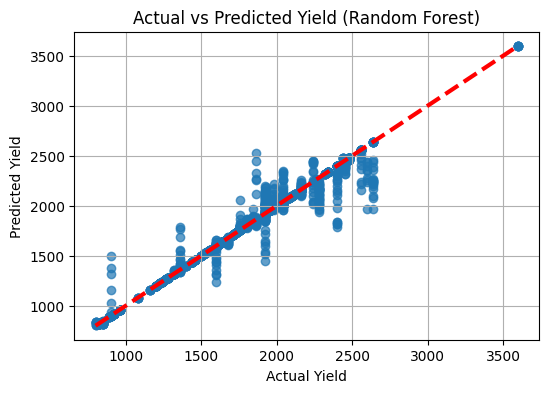

In [ ]:
# visualize Prediction vs Actual
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=3)  # ideal prediction line

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield (Random Forest)")
plt.grid(True)
plt.show()

*Interpretation:*

Points close to the red line → good predictions

Points far from the line → errors

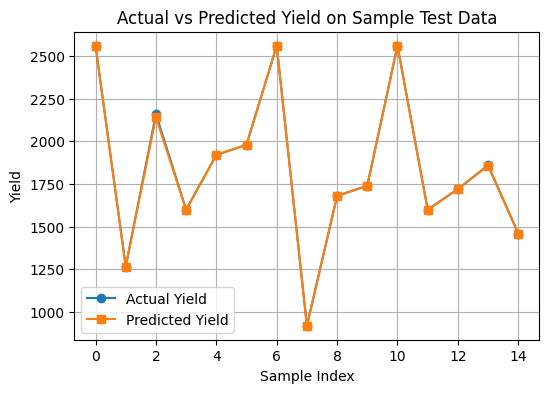

In [ ]:
# Line Plot comparison
sample_results = results.head(15)

plt.figure(figsize=(6, 4))
plt.plot(sample_results.index, sample_results["Actual_Yield"], label="Actual Yield", marker='o')
plt.plot(sample_results.index, sample_results["Predicted_Yield"], label="Predicted Yield", marker='s')

plt.xlabel("Sample Index")
plt.ylabel("Yield")
plt.title("Actual vs Predicted Yield on Sample Test Data")
plt.legend()
plt.grid(True)
plt.show()

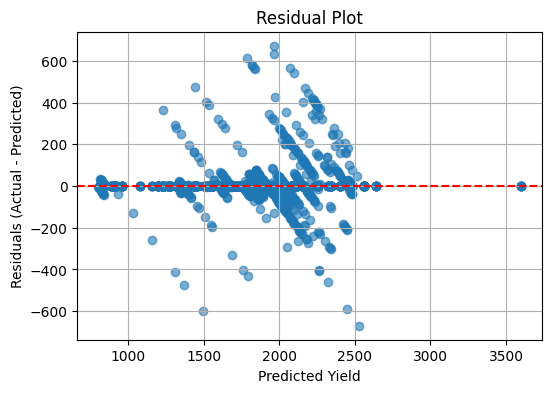

In [ ]:
# Residue plot for error visualization
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Yield")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.grid(True)
plt.show()